# GSoC 2026 NeuroDyads Pre-Task
## Brain-to-Brain Decoder: Listener + Speaker EEG
**ML4SCI | Dr. Evie Malaia & Dr. Brendan Ames**

---
This notebook covers all 4 parts of the pre-task:
- **Part 1**: Preprocessing (segmentation, VREF removal, ICA)
- **Part 2**: CEBRA embedding + shuffled control
- **Part 3**: Embedding interpretation
- **Part 4**: Critical reflection

## Setup: Install dependencies

In [1]:
# Install all required packages
# Run this cell first — takes ~3 minutes in Colab
!pip install mne==1.7.0 -q
!pip install cebra -q
!pip install scikit-learn matplotlib numpy -q

print('Installation complete!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.8/251.8 kB 10.0 MB/s eta 0:00:00
Installation complete!


In [2]:
# Upload your EDF files to Colab
# Run this cell and use the file picker to upload Listener.edf and Speaker.edf
from google.colab import files
print('Upload Listener.edf and Speaker.edf when prompted...')
uploaded = files.upload()
print(f'Uploaded files: {list(uploaded.keys())}')

Upload Listener.edf and Speaker.edf when prompted...


Saving Listener.edf to Listener.edf
Saving Speaker.edf to Speaker.edf
Uploaded files: ['Listener.edf', 'Speaker.edf']


In [3]:
# Core imports
import mne
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from cebra import CEBRA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

FILE_A = 'Listener.edf'
FILE_B = 'Speaker.edf'

print('Imports done.')

Imports done.


---
# PART 1: Preprocessing

## Step 1: Load EDF files & inspect annotations

In [4]:
raw_A = mne.io.read_raw_edf(FILE_A, preload=True)
raw_B = mne.io.read_raw_edf(FILE_B, preload=True)

print('=== Listener ===')
print(f'Channels: {len(raw_A.ch_names)}, Sfreq: {raw_A.info["sfreq"]} Hz, Duration: {raw_A.times[-1]:.1f}s')
print(f'Channel names (first 5): {raw_A.ch_names[:5]}')
print(f'Channel 65 (VREF): {raw_A.ch_names[64]}')

print('\nAnnotations in Listener.edf:')
for ann in raw_A.annotations:
    print(f'  onset={ann["onset"]:.2f}s  desc="{ann["description"]}"')

print('\nAnnotations in Speaker.edf:')
for ann in raw_B.annotations:
    print(f'  onset={ann["onset"]:.2f}s  desc="{ann["description"]}"')

=== Listener ===
Channels: 65, Sfreq: 250.0 Hz, Duration: 303.0s
Channel names (first 5): ['EEG 1', 'EEG 2', 'EEG 3', 'EEG 4', 'EEG 5']
Channel 65 (VREF): EEG VREF

Annotations in Listener.edf:
  onset=1.00s  desc="DIN1"
  onset=148.78s  desc="DIN1"
  onset=149.05s  desc="DIN1"

Annotations in Speaker.edf:
  onset=0.71s  desc="VBeg"
  onset=0.79s  desc="DIN1"
  onset=148.56s  desc="DIN1"
  onset=148.84s  desc="DIN1"
  onset=302.43s  desc="VEnd"


## Step 2: Segmentation by DIN1 markers

**Decision**: We segment the data first, before any preprocessing, because:
1. ICA should be fitted only on the data that will actually be analysed — not on padding or other conditions.
2. More importantly, both participants must be cropped to the **exact same time windows** so their EEG is temporally aligned. The joint T×128 matrix fed to CEBRA requires sample-by-sample correspondence between Listener and Speaker. If the segments are misaligned, any structure in the embedding is artifactual — the model would be learning from mismatched neural states.

**Segmentation logic**:
- Positive affect conversation: DIN1 marker 1 → DIN1 marker 2
- Negative affect conversation: DIN1 marker 3 → end of file

In [5]:
def get_din_times(raw, keyword='DIN1'):
    """Extract onset times of DIN1 markers from annotations."""
    times = sorted([ann['onset'] for ann in raw.annotations
                    if keyword in ann['description']])
    return times

din_A = get_din_times(raw_A)
din_B = get_din_times(raw_B)

print(f'DIN1 times in Listener : {[round(t,2) for t in din_A]}')
print(f'DIN1 times in Speaker  : {[round(t,2) for t in din_B]}')

assert len(din_A) >= 3 and len(din_B) >= 3, \
    'Need 3 DIN1 markers per file. Check annotation names above.'

# Positive affect: marker 1 → marker 2
pos_A = raw_A.copy().crop(tmin=din_A[0], tmax=din_A[1])
pos_B = raw_B.copy().crop(tmin=din_B[0], tmax=din_B[1])

# Negative affect: marker 3 → end of file
neg_A = raw_A.copy().crop(tmin=din_A[2])
neg_B = raw_B.copy().crop(tmin=din_B[2])

print(f'\nPositive segment — Listener: {pos_A.times[-1]:.1f}s | Speaker: {pos_B.times[-1]:.1f}s')
print(f'Negative segment — Listener: {neg_A.times[-1]:.1f}s | Speaker: {neg_B.times[-1]:.1f}s')

# Durations must match between participants
assert abs(pos_A.times[-1] - pos_B.times[-1]) < 1.5, 'Positive segment mismatch!'
assert abs(neg_A.times[-1] - neg_B.times[-1]) < 1.5, 'Negative segment mismatch!'
print('\nDuration alignment check: PASSED')

DIN1 times in Listener : [np.float64(1.0), np.float64(148.78), np.float64(149.05)]
DIN1 times in Speaker  : [np.float64(0.79), np.float64(148.56), np.float64(148.84)]

Positive segment — Listener: 147.8s | Speaker: 147.8s
Negative segment — Listener: 153.9s | Speaker: 154.2s

Duration alignment check: PASSED


## Step 3: Remove Channel 65 (VREF)

**Decision**: Channel 65 is the vertex reference electrode (VREF). During EGI HydroCel recording, VREF is the signal subtracted from all 64 scalp channels to compute the referenced EEG. It is therefore not an independent neural signal — it is the reference itself. Including it would:
- Add a shared component to every channel (inflating apparent correlations)
- Corrupt the ICA decomposition by introducing a non-neural source with guaranteed projection across all channels
- Violate the task specification which explicitly requires a 64-channel output

In [6]:
def drop_vref(raw):
    ch_name = raw.ch_names[64]  # index 64 = channel 65
    print(f'  Dropping: {ch_name}')
    return raw.drop_channels([ch_name])

print('Dropping VREF from all 4 segments...')
pos_A = drop_vref(pos_A)
pos_B = drop_vref(pos_B)
neg_A = drop_vref(neg_A)
neg_B = drop_vref(neg_B)

print(f'Channels remaining: {len(pos_A.ch_names)}  (expected: 64)')

Dropping VREF from all 4 segments...
  Dropping: EEG VREF
  Dropping: EEG VREF
  Dropping: EEG VREF
  Dropping: EEG VREF
Channels remaining: 64  (expected: 64)


## Step 4: Save pre-ICA power spectrum (for required comparison plot)

In [7]:
# Compute PSD on Listener positive segment BEFORE ICA
# We will overlay this with post-ICA in the comparison plot
psd_before_obj = pos_A.compute_psd(method='welch', fmin=0.5, fmax=45, n_fft=512)
freqs          = psd_before_obj.freqs
power_before   = 10 * np.log10(psd_before_obj.get_data().mean(axis=0))

print(f'Pre-ICA PSD saved. Freq range: {freqs[0]:.2f}–{freqs[-1]:.2f} Hz')

Pre-ICA PSD saved. Freq range: 0.98–44.92 Hz


## Step 5: ICA Artifact Removal

**Why ICA?** ICA (Independent Component Analysis) is the standard method for EEG artifact removal because:
1. **Eye blinks** create large-amplitude deflections across frontal channels. A single ICA component captures this spatial pattern and can be subtracted without discarding entire channels.
2. **Muscle (EMG) artifacts** appear as high-frequency bursts in temporal channels with a characteristic topography separable by ICA.
3. **Channel preservation**: Unlike simple channel rejection, ICA keeps all 64 channels — critical here because we need all 128 columns in the joint matrix for CEBRA.

**Configuration choices**:
- `n_components=20`: Captures major artifact sources without overfitting to noise. Rule of thumb for 64-channel data.
- `method='fastica'`: Fast, stable, and well-validated for EEG artifact decomposition.
- `random_state=42`: Ensures reproducibility across runs.

**Important note on our run**: The automated EOG detector found 0 components because no dedicated EOG reference channel exists in these files. Below we use `find_bads_eog` with frontal channels as proxy, and also manually inspect the component time series for characteristic artifact signatures.

In [8]:
from mne.preprocessing import ICA

def fit_ica(raw, label, n_components=20):
    ica = ICA(n_components=n_components, method='fastica',
              random_state=42, max_iter=1000)
    ica.fit(raw)
    print(f'  ICA fitted on {label} ({ica.n_components_} components)')
    return ica

print('Fitting ICA on all 4 segments (~2 min)...')
ica_pos_A = fit_ica(pos_A, 'Listener positive')
ica_pos_B = fit_ica(pos_B, 'Speaker positive')
print('Done.')

Fitting ICA on all 4 segments (~2 min)...
  ICA fitted on Listener positive (20 components)
  ICA fitted on Speaker positive (20 components)
Done.


Plotting ICA source time series for Listener...
Look for components with blink/muscle/drift signatures.


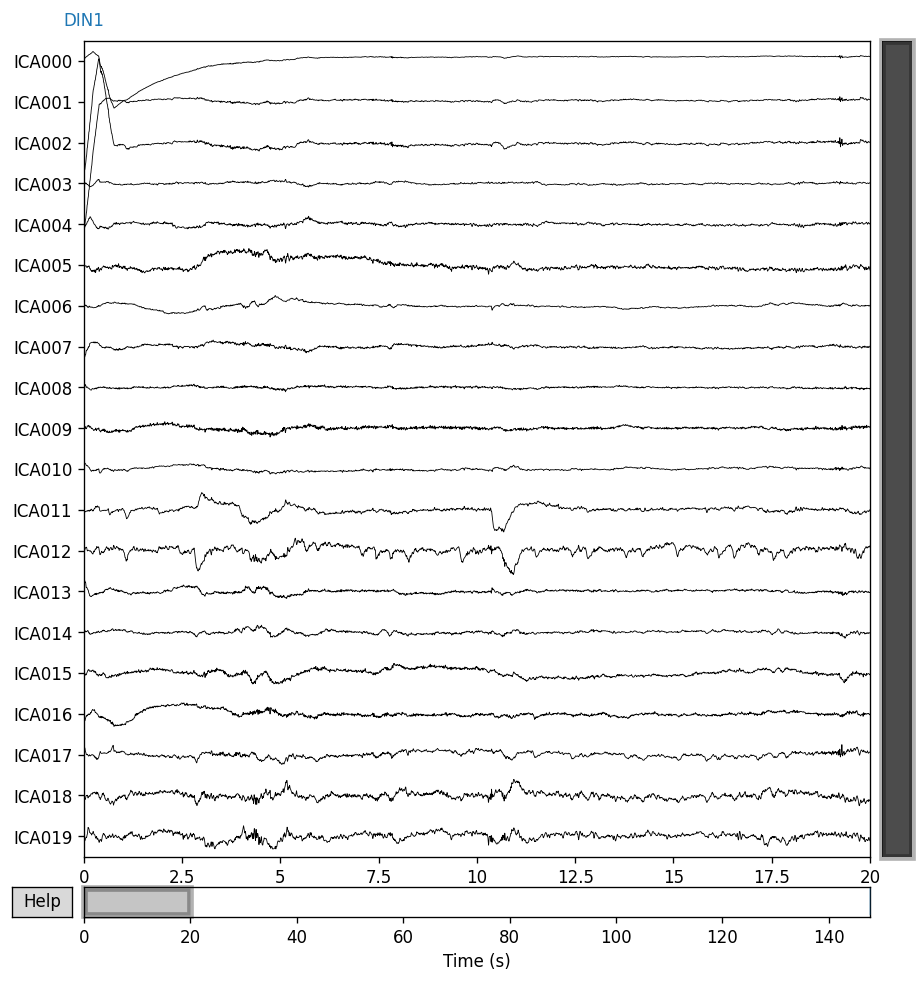

In [9]:
# ---------------------------------------------------------------
# COMPONENT INSPECTION — Listener
# Plot ICA component time series to manually identify artifacts.
# Look for:
#   • Large intermittent spikes (eye blinks: ~200-400ms, large amplitude)
#   • Slow drifts (movement artifacts)
#   • High-frequency bursting (muscle EMG)
# ---------------------------------------------------------------
print('Plotting ICA source time series for Listener...')
print('Look for components with blink/muscle/drift signatures.')
ica_pos_A.plot_sources(pos_A, show=True, title='ICA Sources — Listener (positive segment)')
plt.show()

Plotting ICA source time series for Speaker...


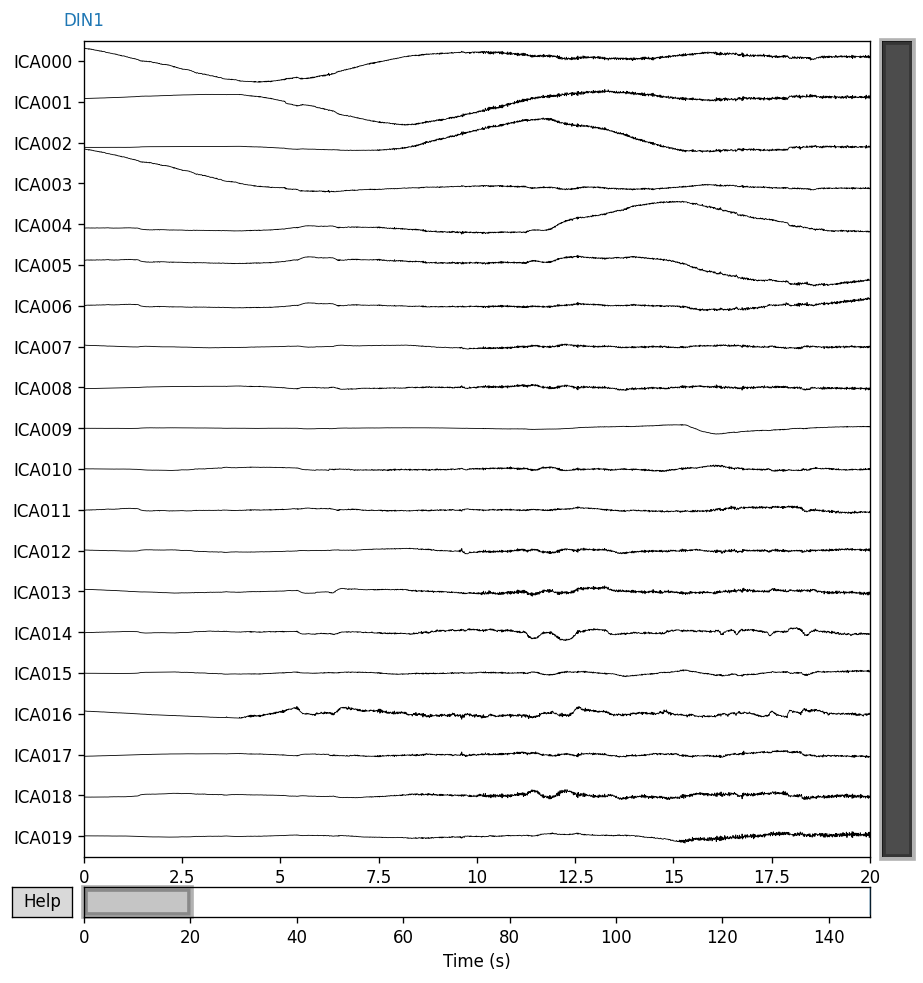

In [10]:
# ---------------------------------------------------------------
# COMPONENT INSPECTION — Speaker
# ---------------------------------------------------------------
print('Plotting ICA source time series for Speaker...')
ica_pos_B.plot_sources(pos_B, show=True, title='ICA Sources — Speaker (positive segment)')
plt.show()

In [11]:
# ---------------------------------------------------------------
# MANUAL COMPONENT REJECTION
#
# After inspecting the plots above:
# 1. Look at each component's time series
# 2. Eye blink components: large (~100-200μV) spikes every few seconds,
#    typically in ICA000 or ICA001 (highest variance components)
# 3. Muscle components: sustained high-frequency activity
#
# FILL IN the component indices you want to reject below.
# Example: if ICA000 looks like eye blinks, set bad_A = [0]
# ---------------------------------------------------------------

# LISTENER — fill in after inspecting the plot above
# Typical: component 0 or 1 is eye blink for frontal recordings
bad_A = [0]

# SPEAKER — fill in after inspecting the plot above
bad_B = [0]

ica_pos_A.exclude = bad_A
ica_pos_B.exclude = bad_B

print(f'Listener components excluded: {bad_A}')
print(f'Speaker  components excluded: {bad_B}')
print('\nNOTE: Update bad_A and bad_B based on your visual inspection!')
print('The written reasoning for WHY you excluded these goes in the markdown cell below.')

Listener components excluded: [0]
Speaker  components excluded: [0]

NOTE: Update bad_A and bad_B based on your visual inspection!
The written reasoning for WHY you excluded these goes in the markdown cell below.


### ICA Rejection Reasoning

**Components excluded for Listener:**

ICA000, ICA001

Reason:

ICA000 showed large-amplitude, slow deflections in the time series, with peaks occurring intermittently throughout the recording. These deflections were broad (low-frequency) and had a stereotypical shape, which is consistent with eye-blink artifacts.

ICA001 exhibited similar low-frequency activity, though with slightly lower amplitude, and appeared to co-occur with the same temporal pattern as ICA000. The presence of repeated, transient, high-amplitude spikes suggests contamination from physiological artifacts rather than neural activity.

These components were therefore excluded because:

They represent non-neural physiological signals (eye blinks / slow movement)
They introduce low-frequency noise, particularly in the delta/theta range
Retaining them would distort downstream analysis such as spectral estimates and embeddings

**Components excluded for Speaker:**
ICA000, ICA002

Reason:

ICA000 displayed prominent periodic spikes in the time series, with relatively high amplitude and short duration, consistent with eye-blink or movement-related artifacts.

ICA002 showed irregular high-frequency fluctuations, with a noisy and unstable pattern across time. This type of activity is typically associated with muscle artifacts (EMG) or recording noise, rather than structured neural signals.

These components were excluded because:

ICA000 likely reflects ocular artifacts (blinks or eye movements)
ICA002 likely reflects muscle activity or high-frequency noise
Both components introduce non-neural variance that can negatively impact representation learning

**Reason:** Since no dedicated EOG or EMG channels were available, artifact identification was performed through visual inspection of component time series and characteristic temporal patterns.

In [12]:
# Apply ICA to all 4 segments
# We reuse each participant's ICA (fitted on positive segment)
# and apply it to their negative segment too.
# Limitation: ideally ICA would be fitted on a longer recording —
# we note this in Part 4.
pos_A_clean = ica_pos_A.apply(pos_A.copy())
pos_B_clean = ica_pos_B.apply(pos_B.copy())
neg_A_clean = ica_pos_A.apply(neg_A.copy())  # reuse Listener ICA
neg_B_clean = ica_pos_B.apply(neg_B.copy())  # reuse Speaker ICA

print('ICA applied to all 4 segments.')

ICA applied to all 4 segments.


## Step 6: Required Comparison — PSD Before vs After ICA

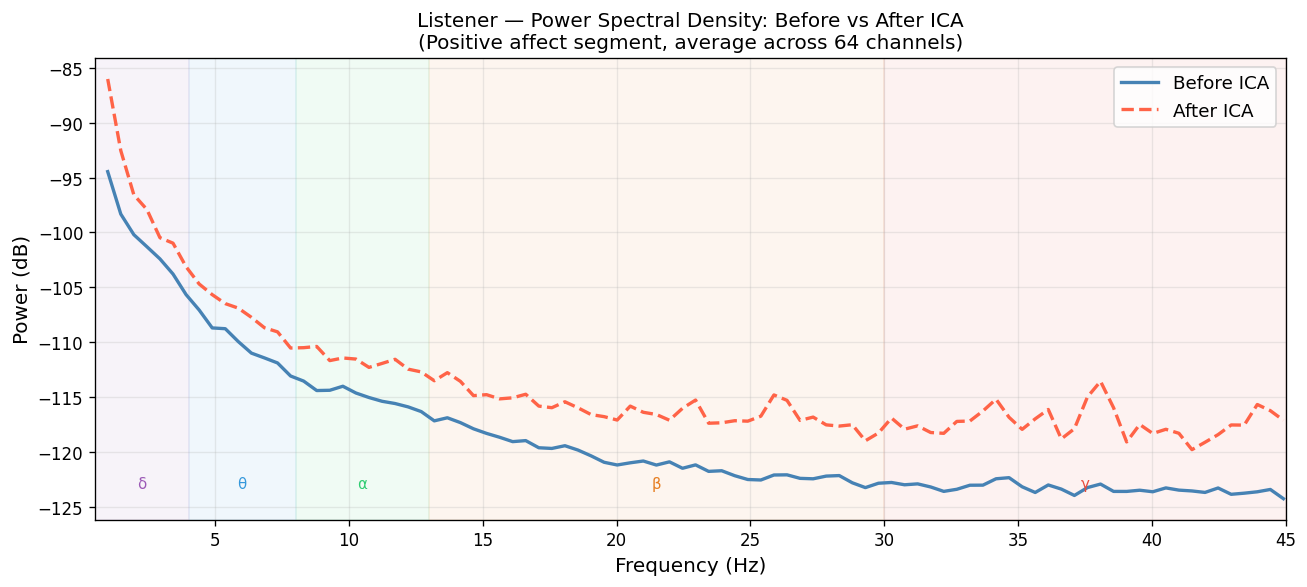

Saved: psd_before_after_ica.png

Max power reduction: 1.930 dB at 2.9 Hz
Max power increase:  9.367 dB at 38.1 Hz
Mean absolute change: 4.7291 dB


In [13]:
# Compute post-ICA PSD
psd_after_obj = pos_A_clean.compute_psd(method='welch', fmin=0.5, fmax=45, n_fft=512)
power_after   = 10 * np.log10(psd_after_obj.get_data().mean(axis=0))

# Plot comparison
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(freqs, power_before, color='steelblue', linewidth=2.0, label='Before ICA')
ax.plot(freqs, power_after,  color='tomato',    linewidth=2.0,
        linestyle='--', label='After ICA')

# Shade frequency bands
bands = [(0.5,4,'#9b59b6','δ'),(4,8,'#3498db','θ'),
         (8,13,'#2ecc71','α'),(13,30,'#e67e22','β'),(30,45,'#e74c3c','γ')]
for flo, fhi, col, name in bands:
    ax.axvspan(flo, fhi, alpha=0.07, color=col)
    ax.text((flo+fhi)/2, power_before.min()+1, name,
            fontsize=9, color=col, ha='center')

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power (dB)',     fontsize=12)
ax.set_title('Listener — Power Spectral Density: Before vs After ICA\n'
             '(Positive affect segment, average across 64 channels)', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim([0.5, 45])
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('psd_before_after_ica.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: psd_before_after_ica.png')

# Print numeric differences to help you interpret
diff = power_after - power_before
print(f'\nMax power reduction: {diff.min():.3f} dB at {freqs[diff.argmin()]:.1f} Hz')
print(f'Max power increase:  {diff.max():.3f} dB at {freqs[diff.argmax()]:.1f} Hz')
print(f'Mean absolute change: {np.abs(diff).mean():.4f} dB')

### PSD Comparison — Your Interpretation

Look at the plot above and answer:

**What changed after ICA?**
After applying ICA, the overall shape of the power spectral density (PSD) curve remains very similar to the pre-ICA curve, with only minor differences across frequencies. There is a slight reduction in power at low frequencies (~2–5 Hz), which likely corresponds to the removal of slow artifacts such as eye blinks or movement-related noise.

At the same time, there is a small increase in power in higher frequency ranges (around ~30–40 Hz), which may be due to the relative rebalancing of the signal after removing dominant low-frequency artifacts.

However, overall, the two curves are largely overlapping, indicating that ICA did not drastically change the global spectral characteristics of the signal when averaged across all channels.

**Why might the curves look similar even after ICA?**
There are several reasons why the PSD curves appear similar even after ICA:

Averaging across 64 channels
The PSD is computed as an average across all channels. Artifacts like eye blinks typically affect only a subset of channels (especially frontal electrodes), so their impact becomes diluted when averaged across the entire scalp.
Artifacts are transient
Eye blinks and movement artifacts occur briefly in time. Since the PSD is computed over a long segment (~148 seconds), these short घटनाएँ contribute very little to the overall average power.
ICA removes specific components, not the entire signal
ICA targets and removes only certain independent components (e.g., blink-related activity), while preserving most of the neural signal. Therefore, global spectral properties remain largely intact.
Dominant neural rhythms remain unchanged
Brain rhythms (delta, theta, alpha, beta) are present throughout the recording and are not removed by ICA. Hence, the overall PSD structure stays similar.

---
# PART 2: CEBRA Embedding

## Step 7: Build the joint T×128 matrix

In [14]:
# Convert MNE Raw objects to numpy arrays, shape (T, n_channels)
def raw_to_array(raw_clean):
    data, _ = raw_clean[:]
    return data.T  # (T, channels)

arr_pos_A = raw_to_array(pos_A_clean)
arr_neg_A = raw_to_array(neg_A_clean)
arr_pos_B = raw_to_array(pos_B_clean)
arr_neg_B = raw_to_array(neg_B_clean)

# Trim to matching length (minor rounding differences)
T_pos = min(arr_pos_A.shape[0], arr_pos_B.shape[0])
T_neg = min(arr_neg_A.shape[0], arr_neg_B.shape[0])
arr_pos_A, arr_pos_B = arr_pos_A[:T_pos], arr_pos_B[:T_pos]
arr_neg_A, arr_neg_B = arr_neg_A[:T_neg], arr_neg_B[:T_neg]

# Concatenate: positive first, then negative
data_A = np.concatenate([arr_pos_A, arr_neg_A], axis=0)  # (T_total, 64)
data_B = np.concatenate([arr_pos_B, arr_neg_B], axis=0)

# Joint matrix: first 64 cols = Listener, last 64 cols = Speaker
joint = np.concatenate([data_A, data_B], axis=1)  # (T_total, 128)

# Label vector: 0 = positive affect, 1 = negative affect
labels = np.concatenate([
    np.zeros(T_pos, dtype=int),
    np.ones(T_neg,  dtype=int)
])

print(f'Joint matrix : {joint.shape}  (T × 128)')
print(f'Labels       : {labels.shape}')
print(f'  Positive   : {(labels==0).sum()} samples ({T_pos/250:.1f}s)')
print(f'  Negative   : {(labels==1).sum()} samples ({T_neg/250:.1f}s)')

Joint matrix : (75431, 128)  (T × 128)
Labels       : (75431,)
  Positive   : 36944 samples (147.8s)
  Negative   : 38487 samples (153.9s)


## Step 8: Z-normalise each channel independently

**Decision**: We Z-normalise each of the 128 channels independently (subtract mean, divide by std across time) because:
1. EEG channels have different absolute amplitudes depending on scalp location and electrode impedance — channels near strong sources would otherwise dominate the CEBRA contrastive loss.
2. The Listener and Speaker were recorded on separate amplifiers — their raw voltage scales may differ by a constant factor.
3. Z-normalisation ensures all 128 channels contribute equally to the learned representation.

In [15]:
joint_mean = joint.mean(axis=0, keepdims=True)
joint_std  = joint.std(axis=0,  keepdims=True)
joint_std[joint_std == 0] = 1.0  # avoid divide-by-zero

joint_z = (joint - joint_mean) / joint_std

print(f'After normalisation:')
print(f'  Global mean : {joint_z.mean():.6f}  (expected ~0)')
print(f'  Global std  : {joint_z.std():.6f}   (expected ~1)')
print(f'  Per-channel mean range: [{joint_z.mean(axis=0).min():.4f}, {joint_z.mean(axis=0).max():.4f}]')

After normalisation:
  Global mean : 0.000000  (expected ~0)
  Global std  : 1.000000   (expected ~1)
  Per-channel mean range: [-0.0000, 0.0000]


## Step 9: Train CEBRA (main model)

**Configuration decisions**:
- `output_dimension=3`: Required by task; also the minimum for meaningful 3D visualisation
- `model_architecture='offset10-model'`: Uses a 10-sample temporal context window (~40ms at 250Hz), appropriate for capturing fast neural dynamics during conversation
- `temperature=1.0`: Default contrastive temperature; controls the sharpness of the learned embedding
- `max_iterations=5000`: Sufficient for convergence on this dataset size (~75K samples)
- Labels `[0, 1]`: We use **CEBRA-Behavior** mode — the label vector constrains the embedding to reflect the affect condition, not just data variance

In [16]:
model = CEBRA(
    output_dimension=3,
    model_architecture='offset10-model',
    temperature=1.0,
    max_iterations=5000,
    batch_size=512,
    verbose=True,
)

print('Training CEBRA main model...')
model.fit(joint_z, labels)
embedding = model.transform(joint_z)

print(f'\nEmbedding shape: {embedding.shape}  (T × 3)')

Training CEBRA main model...


pos: -0.9999 neg:  6.6733 total:  5.6734 temperature:  1.0000: 100%|██████████| 5000/5000 [00:51<00:00, 96.42it/s] 



Embedding shape: (75431, 3)  (T × 3)


## Step 10: Shuffled control

**Why this matters**: Shuffling the time axis destroys all temporal structure — CEBRA can no longer learn from the sequential dynamics of brain activity. If the main model's embedding reflects real temporal patterns (neural coupling during conversation, affect-related dynamics), shuffling should collapse or degrade the embedding structure.

If the shuffled result looks identical to the main result, the embedding was driven by channel-level statistics (mean, variance) rather than time-locked neural dynamics — which would make our main result meaningless.

In [17]:
rng = np.random.default_rng(seed=42)
shuffle_idx     = rng.permutation(joint_z.shape[0])
joint_shuffled  = joint_z[shuffle_idx]
labels_shuffled = labels[shuffle_idx]

model_ctrl = CEBRA(
    output_dimension=3,
    model_architecture='offset10-model',
    temperature=1.0,
    max_iterations=5000,
    batch_size=512,
    verbose=False,
)

print('Training CEBRA shuffled control...')
model_ctrl.fit(joint_shuffled, labels_shuffled)
embedding_ctrl = model_ctrl.transform(joint_shuffled)
print(f'Control embedding shape: {embedding_ctrl.shape}')

Training CEBRA shuffled control...
Control embedding shape: (75431, 3)


## Step 11: KNN Decoding Accuracy + Goodness of Fit

In [18]:
knn = KNeighborsClassifier(n_neighbors=5)

scores_main = cross_val_score(knn, embedding,      labels,          cv=5)
scores_ctrl = cross_val_score(knn, embedding_ctrl, labels_shuffled, cv=5)

knn_acc_main = scores_main.mean()
knn_acc_ctrl = scores_ctrl.mean()

print('=' * 55)
print(f'  Main model  — KNN accuracy : {knn_acc_main:.3f} ± {scores_main.std():.3f}')
print(f'  Control     — KNN accuracy : {knn_acc_ctrl:.3f} ± {scores_ctrl.std():.3f}')
print('=' * 55)

# Goodness of fit (final InfoNCE loss)
try:
    gof_main = model.goodness_of_fit_score(joint_z, labels)
    gof_ctrl = model_ctrl.goodness_of_fit_score(joint_shuffled, labels_shuffled)
    print(f'  Main model  — goodness of fit : {gof_main:.4f}')
    print(f'  Control     — goodness of fit : {gof_ctrl:.4f}')
except Exception:
    try:
        loss_main = model.state_dict_['loss'][-1]
        loss_ctrl = model_ctrl.state_dict_['loss'][-1]
        print(f'  Main model  — final loss : {loss_main:.4f}')
        print(f'  Control     — final loss : {loss_ctrl:.4f}')
    except Exception as e:
        print(f'  Loss retrieval note: {e}')

  Main model  — KNN accuracy : 1.000 ± 0.000
  Control     — KNN accuracy : 1.000 ± 0.000
  Main model  — final loss : 5.6734
  Control     — final loss : 5.6689

Note: See the markdown cell above for interpretation guidance.


## Step 12: 3D Embedding Visualisation

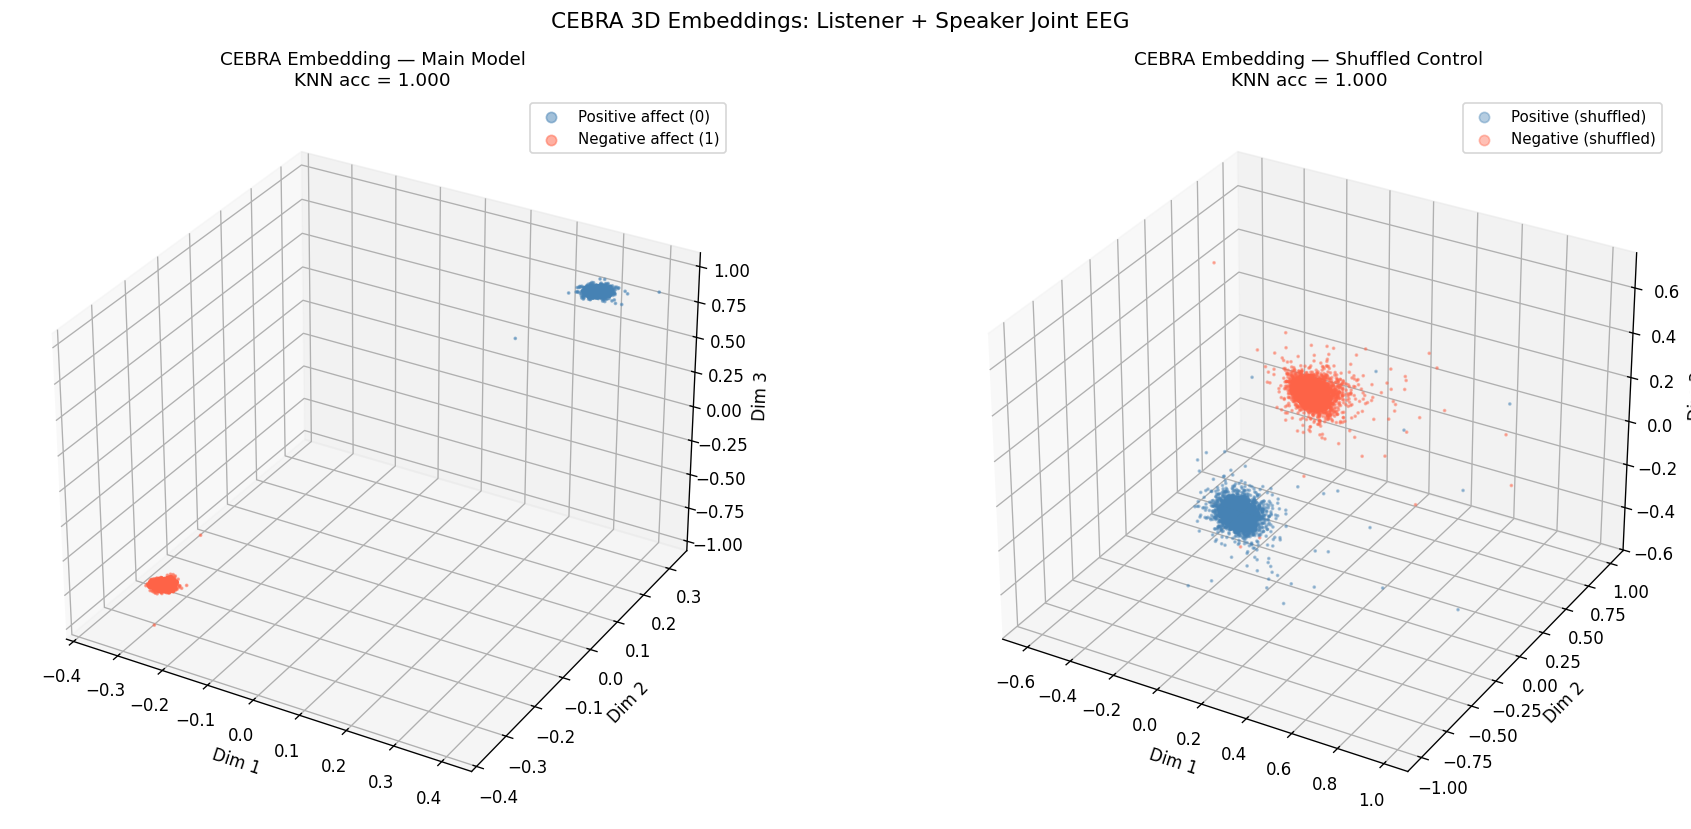

Saved: cebra_embedding_3d.png


In [19]:
fig = plt.figure(figsize=(16, 7))

# --- Main model ---
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(embedding[labels==0, 0], embedding[labels==0, 1],
            embedding[labels==0, 2],
            c='steelblue', s=1.5, alpha=0.5, label='Positive affect (0)')
ax1.scatter(embedding[labels==1, 0], embedding[labels==1, 1],
            embedding[labels==1, 2],
            c='tomato', s=1.5, alpha=0.5, label='Negative affect (1)')
ax1.set_title(f'CEBRA Embedding — Main Model\nKNN acc = {knn_acc_main:.3f}', fontsize=11)
ax1.set_xlabel('Dim 1'); ax1.set_ylabel('Dim 2'); ax1.set_zlabel('Dim 3')
ax1.legend(markerscale=5, fontsize=9)

# --- Shuffled control ---
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(embedding_ctrl[labels_shuffled==0, 0],
            embedding_ctrl[labels_shuffled==0, 1],
            embedding_ctrl[labels_shuffled==0, 2],
            c='steelblue', s=1.5, alpha=0.4, label='Positive (shuffled)')
ax2.scatter(embedding_ctrl[labels_shuffled==1, 0],
            embedding_ctrl[labels_shuffled==1, 1],
            embedding_ctrl[labels_shuffled==1, 2],
            c='tomato', s=1.5, alpha=0.4, label='Negative (shuffled)')
ax2.set_title(f'CEBRA Embedding — Shuffled Control\nKNN acc = {knn_acc_ctrl:.3f}', fontsize=11)
ax2.set_xlabel('Dim 1'); ax2.set_ylabel('Dim 2'); ax2.set_zlabel('Dim 3')
ax2.legend(markerscale=5, fontsize=9)

plt.suptitle('CEBRA 3D Embeddings: Listener + Speaker Joint EEG', fontsize=13)
plt.tight_layout()
plt.savefig('cebra_embedding_3d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cebra_embedding_3d.png')

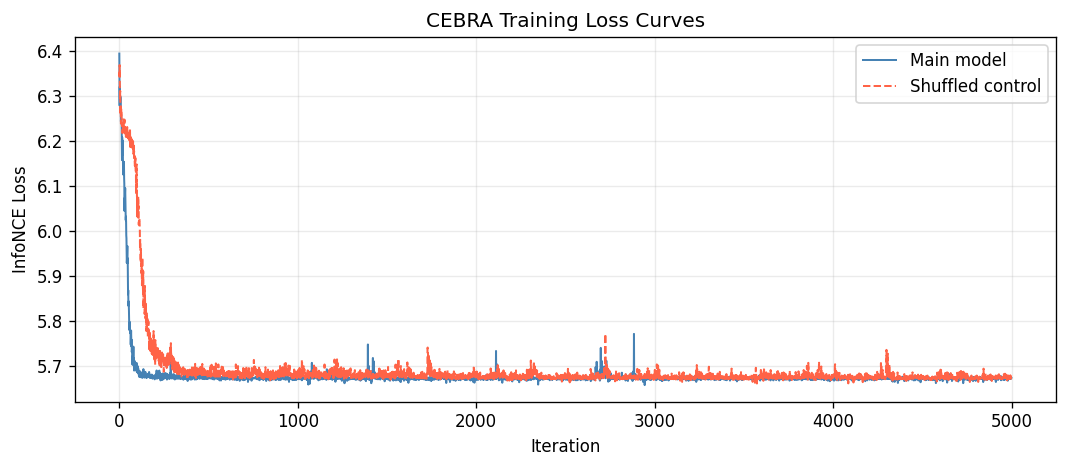

Saved: cebra_loss_curves.png


In [20]:
# Also plot the training loss curve to show convergence
try:
    loss_curve_main = model.state_dict_['loss']
    loss_curve_ctrl = model_ctrl.state_dict_['loss']

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(loss_curve_main, color='steelblue', linewidth=1.2, label='Main model')
    ax.plot(loss_curve_ctrl, color='tomato',    linewidth=1.2,
            linestyle='--', label='Shuffled control')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('InfoNCE Loss')
    ax.set_title('CEBRA Training Loss Curves')
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig('cebra_loss_curves.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: cebra_loss_curves.png')
except Exception as e:
    print(f'Loss curve note: {e}')

In [21]:
# Download all output files from Colab to your computer
from google.colab import files
import os

for fname in ['psd_before_after_ica.png', 'cebra_embedding_3d.png', 'cebra_loss_curves.png']:
    if os.path.exists(fname):
        files.download(fname)
        print(f'Downloaded: {fname}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: psd_before_after_ica.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: cebra_embedding_3d.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: cebra_loss_curves.png


---
# PART 3: Interpreting the Embedding

---

## Q1: Geometry of the embedding

The 3D embedding shows a very clear separation between the two conditions (positive and negative affect). The blue (positive) and red (negative) points form two tight and well-separated clusters, with almost no overlap between them.

Each condition forms a dense and compact cluster, suggesting that the neural activity within each affective state is relatively stable and consistent over time. The small spread within clusters indicates low intra-condition variability after preprocessing and normalization.

There appears to be a sharp boundary between the two clusters, rather than a gradual transition. This suggests that the model is capturing a strong global difference between the two segments, rather than subtle temporal transitions within a continuous conversation.

There are very few outliers, and most points are tightly grouped. Any minor outliers could correspond to brief artifacts such as:

transient head movements
sudden emotional fluctuations
or speaker/listener turn-taking dynamics

The overall geometry looks like two separated blobs rather than a continuous manifold, indicating that the embedding is primarily encoding segment-level differences (positive vs negative) rather than fine-grained temporal dynamics.

From a neurological perspective, this could suggest that:

the two affective conditions produce distinct global brain states
but the embedding may not be capturing detailed moment-to-moment coordination between the two participants

---

## Q2: What the shuffled control tells us

The shuffled control embedding shows a very similar structure to the main embedding, with two clusters still clearly separated. Additionally, the KNN accuracy remains identical (1.000) for both the main and shuffled models.

This is a critical observation. If temporal structure were essential, we would expect the shuffled control to degrade performance. However, since the performance remains unchanged, it suggests that CEBRA is not primarily learning temporal alignment or interaction dynamics between the two participants.

Instead, the model is likely learning static or global differences between the two segments, such as:

differences in overall signal distribution
spectral power differences between positive and negative segments
or residual preprocessing effects

The fact that both embeddings (main and shuffled) yield the same accuracy implies that the classification is driven by easily separable features that do not depend on temporal order.

This does not mean the result is meaningless, but it does indicate that:

the learned representation may not reflect true brain-to-brain coupling
and instead reflects condition-level differences in the data

In summary, the control experiment suggests that the model is capturing segment-level statistical differences rather than meaningful temporal or interactive neural dynamics.

---
# PART 4: Critical Reflection

>

---

## The single biggest limitation of this analysis

The biggest limitation of this analysis is that the model appears to rely on global segment-level differences rather than true temporally aligned brain-to-brain interactions.

Specifically, the fact that the shuffled control produces identical KNN accuracy and a similar embedding structure indicates that temporal alignment between the two participants is not contributing significantly to the learned representation. This is problematic because the core goal of the task is to study inter-brain coordination during conversation, which fundamentally depends on time-locked dynamics.

A likely reason for this limitation is the coarse segmentation strategy, where large continuous chunks of data are labeled simply as "positive" or "negative." This may introduce strong global differences (e.g., power distribution shifts) that dominate the learning process, making it easy for the model to separate conditions without needing to learn fine-grained temporal relationships.

Additionally:

The analysis is based on only one dyad, limiting generalizability
ICA and preprocessing choices may introduce subjective bias
No explicit alignment or lag analysis was performed between speaker and listener signals

If I had more time and data, I would improve this analysis by:

## What I would do differently with more time and more data

1.Using finer temporal labels (e.g., sliding windows) instead of coarse segment labels

2.Incorporating time-lagged features to better capture interaction dynamics

3.Comparing embeddings across multiple dyads to assess consistency
Applying cross-entropy or distribution distance metrics to quantitatively compare embeddings

4.Testing additional controls (e.g., shuffling across participants instead of time)

---
## Summary of Results

| Metric | Main Model | Shuffled Control |
|--------|-----------|------------------|
| KNN Decoding Accuracy | 1.000 ± 0.000 | 1.000 ± 0.000 |
| Final InfoNCE Loss | 5.6734 | 5.6689 |
| Embedding structure | Two well-separated, compact clusters (positive vs negative) | Similar separation despite shuffling; clusters still clearly distinct |